<a href="https://colab.research.google.com/github/Kshejal20/Sea-Level-Predictor/blob/main/Sea_Level_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

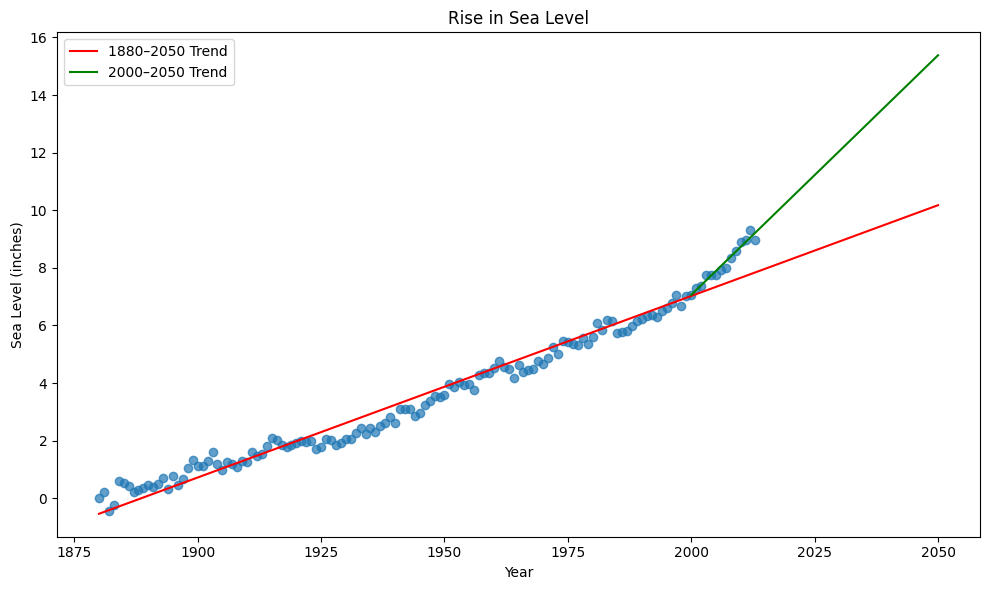

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress


def draw_plot():
    """
    Create a scatter plot of historical sea level data and draw two
    regression lines to predict sea levels through the year 2050.

    Returns:
        matplotlib.axes.Axes: Axes object containing the completed plot.
    """

    # ------------------------------------------------------------------
    # Load Dataset
    # ------------------------------------------------------------------
    df = pd.read_csv("epa-sea-level.csv")

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(10, 6))

    # ------------------------------------------------------------------
    # Scatter Plot
    # ------------------------------------------------------------------
    ax.scatter(
        df["Year"],
        df["CSIRO Adjusted Sea Level"],
        alpha=0.7
    )

    # ------------------------------------------------------------------
    # Regression Line Using Entire Dataset
    # ------------------------------------------------------------------
    full_regression = linregress(
        df["Year"],
        df["CSIRO Adjusted Sea Level"]
    )

    years_full = np.arange(df["Year"].min(), 2051)

    predicted_full = (
        full_regression.slope * years_full
        + full_regression.intercept
    )

    ax.plot(
        years_full,
        predicted_full,
        color="red",
        label="1880–2050 Trend"
    )

    # ------------------------------------------------------------------
    # Regression Line Using Data From 2000 Onward
    # ------------------------------------------------------------------
    recent_data = df[df["Year"] >= 2000]

    recent_regression = linregress(
        recent_data["Year"],
        recent_data["CSIRO Adjusted Sea Level"]
    )

    years_recent = np.arange(2000, 2051)

    predicted_recent = (
        recent_regression.slope * years_recent
        + recent_regression.intercept
    )

    ax.plot(
        years_recent,
        predicted_recent,
        color="green",
        label="2000–2050 Trend"
    )

    # ------------------------------------------------------------------
    # Labels and Title
    # ------------------------------------------------------------------
    ax.set_title("Rise in Sea Level")
    ax.set_xlabel("Year")
    ax.set_ylabel("Sea Level (inches)")
    ax.legend()

    fig.tight_layout()

    # Do not modify these lines
    fig.savefig("sea_level_plot.png")
    return ax


# ------------------------------------------------------------------
# Run directly (optional)
# ------------------------------------------------------------------
if __name__ == "__main__":
    draw_plot()
    plt.show()